# Redes Neurais — 3ª Lista de Exercícios
### Questões 2, 3 e 4
#### Grupo: Gustavo Carvalho e Minnael Campelo

In [ ]:
!pip install scikit-learn matplotlib minisom

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from minisom import MiniSom

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['axes.grid'] = True

---
# Questão 2 — Rede competitiva (K-means)

Classe `KMeans`:
- `n_clusters` = nº de neurônios/centros;
- `init` = inicialização (`'random'`, `'k-means++'` ou um **array** com os centros);
- `n_init` = quantas partidas aleatórias (fica com a de menor inércia);
- atributos do resultado: `cluster_centers_` (centroides), `labels_` (rótulos),
  `inertia_` (**SSE**) e `n_iter_` (nº de iterações até convergir).

In [2]:
# Dados da Questão 2 — 20 amostras, 3 atributos (x1, x2, x3)
X2 = np.array([
    [ 7.82, -4.58, -3.97],   # 1
    [-6.68,  3.16,  2.71],   # 2
    [ 4.36,  2.19,  2.09],   # 3
    [ 6.72,  0.88,  2.80],   # 4
    [-8.64, -3.06,  3.50],   # 5
    [-6.87,  0.57, -5.45],   # 6
    [ 4.47, -2.62,  5.76],   # 7
    [ 6.73, -2.01,  4.18],   # 8
    [-7.71,  2.34, -6.33],   # 9
    [-6.91, -0.49, -5.68],   # 10
    [ 6.18, -2.81,  5.82],   # 11
    [ 6.72, -0.93, -4.04],   # 12
    [-6.25, -0.26,  0.56],   # 13
    [-6.94, -1.22,  1.13],   # 14
    [ 8.09,  0.20,  2.25],   # 15
    [ 6.81,  0.17, -4.15],   # 16
    [-5.19,  4.24,  4.04],   # 17
    [-6.38, -1.74,  1.43],   # 18
    [ 4.08,  1.30,  5.33],   # 19
    [ 6.27,  0.93, -2.78],   # 20
])

def membros(labels, k):
    # para cada cluster, lista os indices (1..n) das amostras
    return {j + 1: [i + 1 for i in range(len(labels)) if labels[i] == j] for j in range(k)}

def resumo(km, titulo):
    print(f"{titulo}: iterações(n_iter_)={km.n_iter_}, SSE(inertia_)={km.inertia_:.2f}")
    print("Centroides (cluster_centers_):")
    print(km.cluster_centers_)
    for cl, m in membros(km.labels_, km.n_clusters).items():
        print(f"  Cluster {cl}: amostras {m}")

### Item (a) — 3 clusters, inicialização aleatória

`init='random'` sorteia amostras como centros; `n_init=10` roda 10 partidas e
mantém a melhor (menor `inertia_`).

In [3]:
km_a = KMeans(n_clusters=3, init='random', n_init=10, random_state=42).fit(X2)
resumo(km_a, "Item (a)")

Item (a): iterações(n_iter_)=2, SSE(inertia_)=269.17
Centroides (cluster_centers_):
[[ 6.905 -1.102 -3.735]
 [ 5.804 -0.41   4.033]
 [-6.841  0.393 -0.454]]
  Cluster 1: amostras [1, 12, 16, 20]
  Cluster 2: amostras [3, 4, 7, 8, 11, 15, 19]
  Cluster 3: amostras [2, 5, 6, 9, 10, 13, 14, 17, 18]


### Item (b) — centros iniciais $m_1=(0,0,0)^t,\ m_2=(0,1,1)^t,\ m_3=(-1,1,2)^t$

Passamos os centros como **array** em `init`; com `init` explícito usa-se `n_init=1`.

In [4]:
init_b = np.array([[0, 0, 0], [0, 1, 1], [-1, 1, 2]], dtype=float)
km_b = KMeans(n_clusters=3, init=init_b, n_init=1).fit(X2)
resumo(km_b, "Item (b)")

Item (b): iterações(n_iter_)=4, SSE(inertia_)=269.17
Centroides (cluster_centers_):
[[ 6.905 -1.102 -3.735]
 [ 5.804 -0.41   4.033]
 [-6.841  0.393 -0.454]]
  Cluster 1: amostras [1, 12, 16, 20]
  Cluster 2: amostras [3, 4, 7, 8, 11, 15, 19]
  Cluster 3: amostras [2, 5, 6, 9, 10, 13, 14, 17, 18]


### Item (c) — centros iniciais quase coincidentes

$m_1=(-0.1,0,0.1)^t,\ m_2=(0,-0.1,0.1)^t,\ m_3=(-0.1,-0.1,0.1)^t$.

In [5]:
init_c = np.array([[-0.1, 0.0, 0.1],
                   [ 0.0, -0.1, 0.1],
                   [-0.1, -0.1, 0.1]], dtype=float)
km_c = KMeans(n_clusters=3, init=init_c, n_init=1).fit(X2)
resumo(km_c, "Item (c)")

Item (c): iterações(n_iter_)=4, SSE(inertia_)=296.28
Centroides (cluster_centers_):
[[-7.163  0.807 -5.82 ]
 [ 6.205 -0.662  1.208]
 [-6.68   0.187  2.228]]
  Cluster 1: amostras [6, 9, 10]
  Cluster 2: amostras [1, 3, 4, 7, 8, 11, 12, 15, 16, 19, 20]
  Cluster 3: amostras [2, 5, 13, 14, 17, 18]


In [ ]:
# Comparacao entre os tres itens
print(f"{'Item':<8}{'n_iter_':>10}{'SSE':>12}")
for nome, km in [('(a)', km_a), ('(b)', km_b), ('(c)', km_c)]:
    print(f"{nome:<8}{km.n_iter_:>10}{km.inertia_:>12.2f}")

part = lambda km: set(map(frozenset, membros(km.labels_, 3).values()))
print("\nItens (a) e (c) chegaram à MESMA partição?", part(km_a) == part(km_c))

Item       n_iter_         SSE
(a)              2      269.17
(b)              4      269.17
(c)              4      296.28

Itens (a) e (c) chegaram à MESMA partição? False


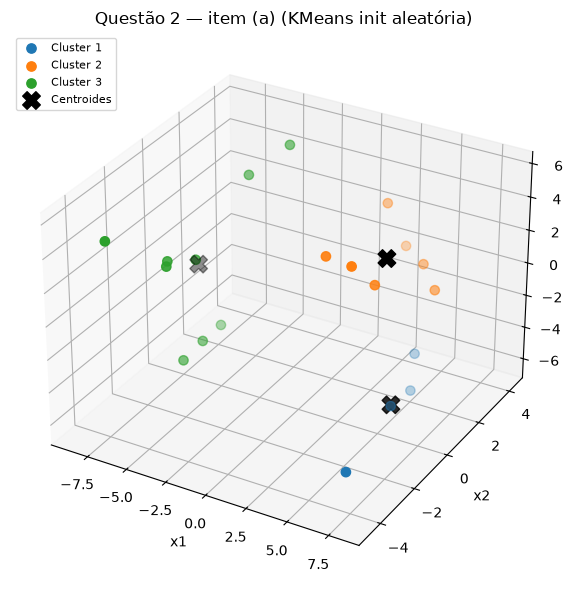

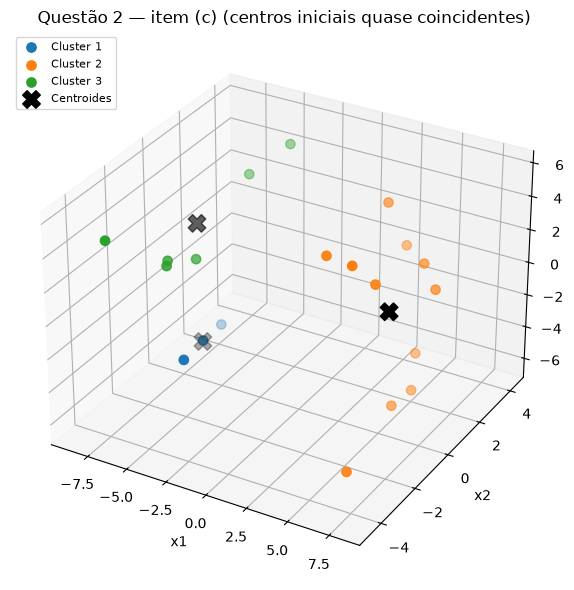

In [ ]:
# Visualizacao 3-D dos clusters
def plot_clusters_3d(X, km, title):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')
    cores = plt.get_cmap('tab10')
    for j in range(km.n_clusters):
        pts = X[km.labels_ == j]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], color=cores(j), s=45, label=f'Cluster {j+1}')
    C = km.cluster_centers_
    ax.scatter(C[:, 0], C[:, 1], C[:, 2], c='k', marker='X', s=160, label='Centroides')
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
    ax.set_title(title); ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout(); plt.show()

plot_clusters_3d(X2, km_a, 'Questão 2 — item (a) (KMeans init aleatória)')
plot_clusters_3d(X2, km_c, 'Questão 2 — item (c) (centros iniciais quase coincidentes)')

### Comparação (a) × (c) e discussão da convergência

**Estrutura dos dados.** `x1` separa um grupo à **direita** (`+4…+8`) de outro à
**esquerda** (`-5…-8`); dentro de cada lado, `x3` separa positivo/negativo → há
**4 "blobs" naturais**, mas pede-se **k = 3**, então uma solução sempre **funde
dois** grupos, e *quais* dependem da inicialização (mínimos locais distintos).

**Resultados (vide saídas acima).** Os itens **(a)** e **(b)** atingem o **menor
SSE (≈269,2)** — fundem os dois blobs da **esquerda** e separam a direita por
`x3`. O item **(c)**, com centros quase coincidentes na origem, cai numa partição
**diferente e de SSE maior (≈296,3)** — um **mínimo local pior** (funde o lado
direito e separa a esquerda).

**Por quê.** Com os três centros quase idênticos e os dados longe (módulo ≈ 8), a
1ª atribuição é decidida por **diferenças minúsculas de coordenada**, gerando uma
partição inicial enviesada que leva o K-means a um ótimo local subótimo. Por isso
o `sklearn` usa por padrão `init='k-means++'` e `n_init>1`: justamente para fugir
desse tipo de inicialização ruim. (Note que o nº de iterações é pequeno em ambos —
a diferença está na **qualidade** da solução, não na velocidade.)

---
# Questão 3 — SOM e PCA para dados 8-D

Quatro gaussianas em $\mathbb{R}^8$, variância unitária, médias
$\mathbf{m}_1=(0,\dots),\ \mathbf{m}_2=(4,0,\dots),\ \mathbf{m}_3=(0,0,0,4,0,\dots),\
\mathbf{m}_4=(0,\dots,0,4)$.

In [ ]:
# Geracao com make_blobs: centers = as 4 medias, cluster_std = 1 (variancia unitaria)
means8 = np.zeros((4, 8))
means8[1, 0] = 4.0
means8[2, 3] = 4.0
means8[3, 7] = 4.0

X3, y3 = make_blobs(n_samples=[150, 150, 150, 150], centers=means8,
                    cluster_std=1.0, random_state=0)
print("Dados:", X3.shape, "| classes:", np.bincount(y3))

Dados: (600, 8) | classes: [150 150 150 150]


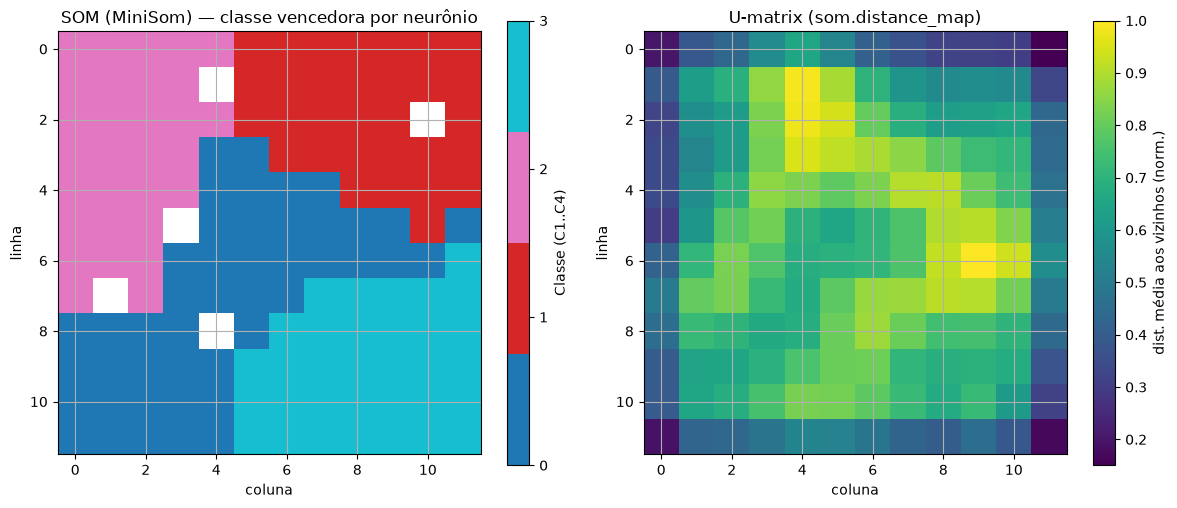

In [ ]:
# SOM com MiniSom (grade 12x12, entrada de dimensao 8)
grid = 12
som3 = MiniSom(grid, grid, 8, sigma=3.0, learning_rate=0.5, random_seed=0)
som3.pca_weights_init(X3)              # inicializa pesos no plano dos 2 maiores PCs
som3.train_random(X3, 10000)           # treina com amostras aleatorias

# classe majoritaria por neuronio (som.labels_map devolve um Counter por neuronio)
lab3 = -np.ones((grid, grid), dtype=int)
for pos, cnt in som3.labels_map(X3, y3).items():
    lab3[pos] = cnt.most_common(1)[0][0]

U3 = som3.distance_map()               # U-matrix (distancias normalizadas) ja pronta

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
disp = np.ma.masked_where(lab3 < 0, lab3)
im0 = ax[0].imshow(disp, cmap=plt.get_cmap('tab10', 4), vmin=0, vmax=3)
ax[0].set_title('SOM (MiniSom) — classe vencedora por neurônio')
ax[0].set_xlabel('coluna'); ax[0].set_ylabel('linha')
fig.colorbar(im0, ax=ax[0], ticks=[0, 1, 2, 3], label='Classe (C1..C4)')
im1 = ax[1].imshow(U3, cmap='viridis')
ax[1].set_title('U-matrix (som.distance_map)')
ax[1].set_xlabel('coluna'); ax[1].set_ylabel('linha')
fig.colorbar(im1, ax=ax[1], label='dist. média aos vizinhos (norm.)')
plt.tight_layout(); plt.show()

**Leitura.** Cada gaussiana ocupa uma **região contígua e distinta** da grade
e a U-matrix mostra "muros" (claros) entre elas: o SOM preserva a topologia das
4 nuvens (bem separadas em 8-D) num mapa 2-D.

### Item 3(a) — mesma visualização via PCA (`sklearn.decomposition.PCA`)

Variância explicada (2 PCs): [0.313 0.285]  soma = 0.598


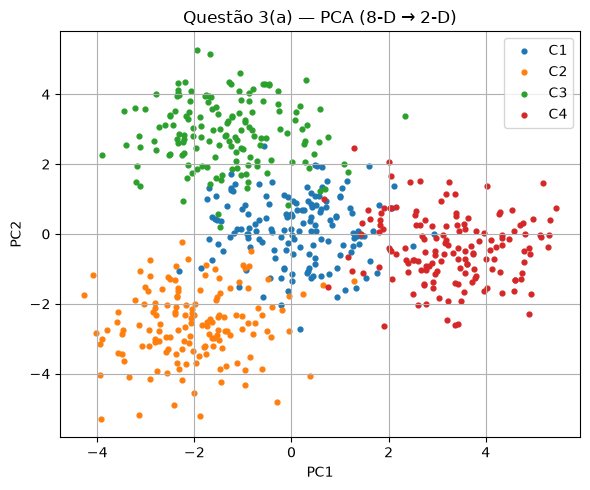

In [10]:
pca3 = PCA(n_components=2).fit(X3)
proj3 = pca3.transform(X3)
print("Variância explicada (2 PCs):", pca3.explained_variance_ratio_,
      " soma =", pca3.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(6, 5))
for c in range(4):
    p = proj3[y3 == c]
    plt.scatter(p[:, 0], p[:, 1], s=12, label=f'C{c+1}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Questão 3(a) — PCA (8-D → 2-D)')
plt.legend(); plt.tight_layout(); plt.show()

**SOM × PCA.** As médias diferem em 3 eixos (1, 4 e 8); com apenas 2
componentes o PCA explica pouco mais da metade da variância e tende a **sobrepor**
um par de classes. O SOM, **não-linear**, separa as 4 nuvens mesmo com a estrutura
em mais de 2 direções — vantagem para visualização.

---
# Questão 4 — SOM e rede competitiva para países

In [ ]:
paises = ['Reino Unido', 'Austrália', 'Canadá', 'Estados Unidos', 'Japão',
          'França', 'Cingapura', 'Argentina', 'Uruguai', 'Cuba', 'Colômbia',
          'Brasil', 'Paraguai', 'Egito', 'Nigéria', 'Senegal', 'Serra Leoa',
          'Angola', 'Etiópia', 'Moçambique', 'China']

# colunas: Expectativa de Vida, Educacao, PIB, Estabilidade Politica
X4 = np.array([
    [0.88, 0.99, 0.91,  0.98], [0.90, 0.99, 0.93,  0.97], [0.90, 0.98, 0.94,  0.99],
    [0.87, 0.98, 0.97,  0.95], [0.93, 0.93, 0.93,  0.96], [0.89, 0.97, 0.92,  0.93],
    [0.88, 0.87, 0.91,  0.98], [0.81, 0.92, 0.80,  0.55], [0.82, 0.92, 0.75,  0.90],
    [0.75, 0.90, 0.64,  0.07], [0.77, 0.85, 0.69, -0.36], [0.71, 0.73, 0.72,  0.67],
    [0.75, 0.83, 0.63,  0.61], [0.70, 0.62, 0.60,  0.21], [0.44, 0.58, 0.37, -0.36],
    [0.47, 0.37, 0.45, -0.68], [0.23, 0.33, 0.27, -0.47], [0.34, 0.36, 0.51, -0.78],
    [0.31, 0.35, 0.32, -0.75], [0.24, 0.37, 0.36,  0.20], [0.76, 0.90, 0.95,  0.98],
])

# Padronizacao z-score com StandardScaler (preenche Media e Desvio Padrao da tabela)
scaler = StandardScaler()
Z4 = scaler.fit_transform(X4)
atributos = ['Expec.Vida', 'Educação', 'PIB', 'Estab.Política']
print(f"{'':<12}" + "".join(f"{a:>15}" for a in atributos))
print(f"{'Média':<12}" + "".join(f"{v:>15.3f}" for v in scaler.mean_))
# StandardScaler usa desvio populacional (ddof=0); mostramos esse valor:
print(f"{'Desv.Padrão':<12}" + "".join(f"{v:>15.3f}" for v in scaler.scale_))

                 Expec.Vida       Educação            PIB Estab.Política
Média                 0.683          0.750          0.694          0.360
Desv.Padrão           0.232          0.245          0.231          0.651


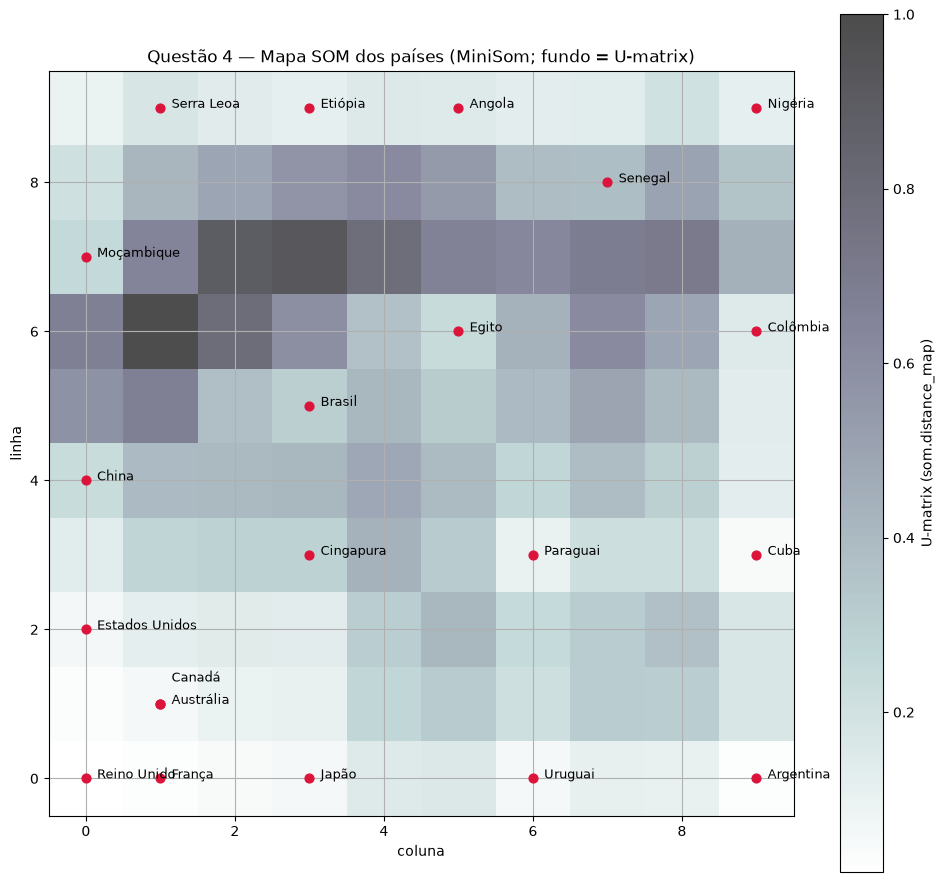

In [ ]:
# SOM 10x10 sobre os dados padronizados
som4 = MiniSom(10, 10, 4, sigma=2.5, learning_rate=0.5, random_seed=3)
som4.pca_weights_init(Z4)
som4.train_random(Z4, 8000)

plt.figure(figsize=(10, 9))
plt.imshow(som4.distance_map(), cmap='bone_r', alpha=0.7)   # U-matrix de fundo
plt.colorbar(label='U-matrix (som.distance_map)')

ocupados = {}
for nome, z in zip(paises, Z4):
    i, j = som4.winner(z)
    n = ocupados.get((i, j), 0); ocupados[(i, j)] = n + 1
    plt.scatter(j, i, s=40, c='crimson', zorder=3)
    plt.text(j + 0.15, i + 0.30 * n, nome, fontsize=9, zorder=4)

plt.title('Questão 4 — Mapa SOM dos países (MiniSom; fundo = U-matrix)')
plt.xlabel('coluna'); plt.ylabel('linha'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

**Leitura.** Países com perfis parecidos caem em neurônios vizinhos:
**desenvolvidos** (Reino Unido, Austrália, Canadá, EUA, Japão, França, Cingapura,
China), **intermediários** (Cuba, Colômbia, Brasil, Paraguai, Egito) e **baixo
desenvolvimento** (Nigéria, Senegal, Serra Leoa, Angola, Etiópia, Moçambique).
**Argentina/Uruguai** ficam na **fronteira** entre desenvolvidos e intermediários.

### Item 4(a) — rede competitiva com KMeans

In [13]:
km4 = KMeans(n_clusters=3, n_init=10, random_state=7).fit(Z4)
print(f"KMeans (k=3): SSE(inertia_)={km4.inertia_:.2f}, iterações={km4.n_iter_}\n")

# ordena clusters do mais desenvolvido ao menos (soma dos centros padronizados)
ordem = np.argsort(-km4.cluster_centers_.sum(axis=1))
nomes_grupo = ['Desenvolvidos', 'Intermediários', 'Baixo desenvolvimento']
for rank, g in enumerate(ordem):
    grp = [paises[i] for i in range(len(paises)) if km4.labels_[i] == g]
    print(f"Cluster {rank+1} ({nomes_grupo[rank]}): {grp}")

print("\nCentros (em z-score) por atributo:")
print(f"{'':<12}" + "".join(f"{a:>15}" for a in atributos))
for rank, g in enumerate(ordem):
    print(f"{'Cluster '+str(rank+1):<12}" + "".join(f"{v:>15.3f}" for v in km4.cluster_centers_[g]))

KMeans (k=3): SSE(inertia_)=8.61, iterações=2

Cluster 1 (Desenvolvidos): ['Reino Unido', 'Austrália', 'Canadá', 'Estados Unidos', 'Japão', 'França', 'Cingapura', 'Argentina', 'Uruguai', 'China']
Cluster 2 (Intermediários): ['Cuba', 'Colômbia', 'Brasil', 'Paraguai', 'Egito']
Cluster 3 (Baixo desenvolvimento): ['Nigéria', 'Senegal', 'Serra Leoa', 'Angola', 'Etiópia', 'Moçambique']

Centros (em z-score) por atributo:
                 Expec.Vida       Educação            PIB Estab.Política
Cluster 1             0.778          0.798          0.898          0.859
Cluster 2             0.227          0.149         -0.164         -0.183
Cluster 3            -1.486         -1.455         -1.360         -1.278


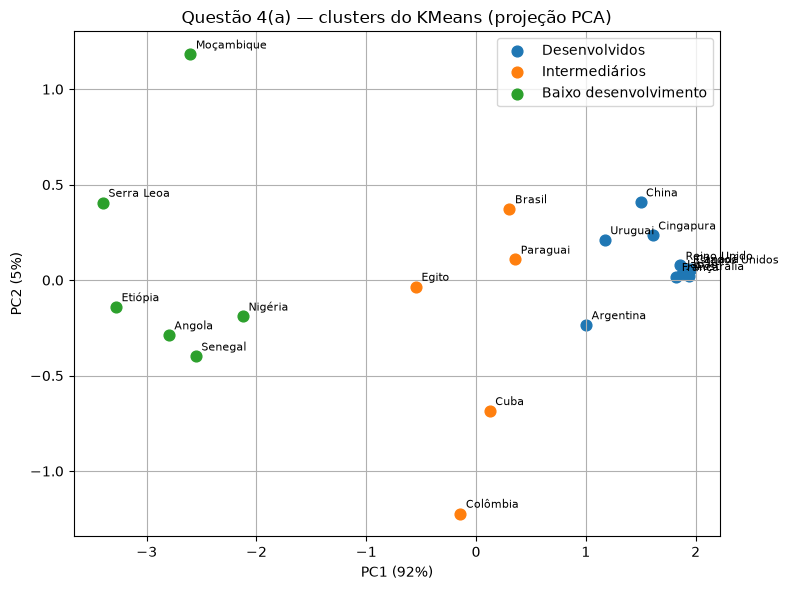

In [ ]:
# Visualizacao 2-D dos clusters via PCA
pca4 = PCA(n_components=2).fit(Z4)
proj4 = pca4.transform(Z4)
vr4 = pca4.explained_variance_ratio_
plt.figure(figsize=(8, 6))
cores = plt.get_cmap('tab10')
for rank, g in enumerate(ordem):
    p = proj4[km4.labels_ == g]
    plt.scatter(p[:, 0], p[:, 1], s=60, color=cores(rank), label=nomes_grupo[rank])
for i, nome in enumerate(paises):
    plt.text(proj4[i, 0] + 0.05, proj4[i, 1] + 0.03, nome, fontsize=8)
plt.xlabel(f'PC1 ({vr4[0]*100:.0f}%)'); plt.ylabel(f'PC2 ({vr4[1]*100:.0f}%)')
plt.title('Questão 4(a) — clusters do KMeans (projeção PCA)')
plt.legend(); plt.tight_layout(); plt.show()

**SOM × rede competitiva.** As duas técnicas concordam: o `KMeans` entrega
direto os **3 clusters** com seus centroides, enquanto o `MiniSom` mostra como
esses grupos se distribuem **continuamente** na grade 2-D — útil para visualizar
similaridade e casos de fronteira (Argentina/Uruguai).